# San Antonio Zillow Housing Analysis

## Exploratory Data Analysis

This notebook presents the exploratory analysis of the finalized San Antonio Zillow housing dataset.

The analysis examines housing prices, property characteristics, geographic differences, Zestimate relationships, and potential factors associated with listing prices.

### Project Focus

- Understand the San Antonio housing market
- Evaluate property and geographic price differences
- Examine relationships between housing characteristics and listing prices
- Assess Zestimate coverage and Zestimate-to-listing-price relationships
- Identify patterns that inform the statistical and machine-learning stages of the project

### Analytical Population

The finalized analytical dataset contains:

- **810 properties**
- **810 unique Zillow property IDs (zpid)**
- **0 duplicate property IDs**

The finalized analytical dataset is the authoritative dataset used throughout the project.

## Project Workflow

The project follows an end-to-end analytical workflow:

```text
Data Collection
      ↓
Data Cleaning
      ↓
Data Quality Analysis
      ↓
Feature Engineering
      ↓
Exploratory Data Analysis
      ↓
Statistical Analysis
      ↓
Machine Learning
      ↓
Model Evaluation
      ↓
SQL Analysis
      ↓
Tableau Visualization
      ↓
Business Insights
```

This notebook focuses specifically on the exploratory-analysis stage while connecting the findings to the later statistical and machine-learning work.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
DATA_PATH = Path("../data/processed/San_Antonio_Zillow_Feature_Engineered.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 810
Columns: 75


## 1. Data Overview

The exploratory analysis begins by examining the structure of the analytical dataset and the primary variables used throughout the project.

In [6]:
df.head()

,zpid,palsId,id,rawHomeStatusCd,marketingStatusSimplifiedCd,imgSrc,hasImage,detailUrl,statusType,statusText,countryCurrency,price,unformattedPrice,address,addressStreet,addressCity,addressState,addressZipcode,isUndisclosedAddress,shouldShowRequestOnPrice,beds,baths,area,latLong,isZillowOwned,flexFieldText,contentType,hdpData,isUserClaimingOwner,isUserConfirmedClaim,pgapt,sgapt,zestimate,shouldShowZestimateAsPrice,has3DModel,hasVideo,isHomeRec,hasAdditionalAttributions,isFeaturedListing,isShowcaseListing,list,relaxed,info3String,info6String,brokerName,carouselPhotosComposable,isPaidBuilderNewConstruction,builderName,providerListingId,hasOpenHouse,openHouseStartDate,openHouseEndDate,openHouseDescription,lotAreaString,availabilityDate,daysOnZillow,homeType,taxAssessedValue,lotAreaValue,lotAreaUnit,priceChange,timeOnZillow,lotAreaSqFt,pricePerSqFt,hasPriceChange,priceQualityFlag,logPrice,zipcode,zestimate_gap,zestimate_gap_pct,opportunity_status,deal_score,price_segment,zip_listing_count,zip_sample_status
0,333537677,44006_2008780,333537677,ForSale,For Sale by Agent,https://photos.zillowstatic.com/fp/3309d14dfbc...,True,https://www.zillow.com/homedetails/11931-Pelic...,FOR_SALE,House for sale,$,"269,000.00",269000,"11931 Pelican Pass, San Antonio, TX 78221",11931 Pelican Pass,San Antonio,TX,78221,False,False,4.00,3.00,1924,"{'latitude': 29.2981, 'longitude': -98.49139}",False,Showcase,showcase,"{'homeInfo': {'zpid': 333537677, 'streetAddres...",False,False,ForSale,For Sale (Broker),"267,100.00",False,True,False,False,True,False,True,True,False,https://photos.zillowstatic.com/fp/7e213a522d6...,Kristen Schramme TREC #568432,Keller Williams Legacy,{'baseUrl': 'https://photos.zillowstatic.com/f...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00,SINGLE_FAMILY,"253,860.00","8,668.44",sqft,NaN,"900,260,000.00","8,668.44",139.81,0,VALID,12.50,78221,"-1,900.00",-0.01,Above Zestimate,83.33,$150K-$300K,11,Sufficient Sample
1,65086008,44006_2009919,65086008,ForSale,For Sale by Agent,https://photos.zillowstatic.com/fp/10e92d85b4f...,True,https://www.zillow.com/homedetails/3222-Navaso...,FOR_SALE,House for sale,$,"449,900.00",449900,"3222 Navasota Cir, San Antonio, TX 78259",3222 Navasota Cir,San Antonio,TX,78259,False,False,4.00,3.00,2626,"{'latitude': 29.64923, 'longitude': -98.43303}",False,Showcase,showcase,"{'homeInfo': {'zpid': 65086008, 'streetAddress...",False,False,ForSale,For Sale (Broker),"441,200.00",False,True,False,False,True,False,True,True,False,https://photos.zillowstatic.com/fp/7e213a522d6...,Shane Neal TREC #608871,eXp Realty,{'baseUrl': 'https://photos.zillowstatic.com/f...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,SINGLE_FAMILY,"469,940.00",0.34,acres,NaN,"478,996,000.00","14,971.57",171.33,0,VALID,13.02,78259,"-8,700.00",-0.02,Above Zestimate,45.31,$300K-$500K,17,Sufficient Sample
2,83988085,44006_2010335,83988085,ForSale,For Sale by Agent,https://photos.zillowstatic.com/fp/4256b85b9cf...,True,https://www.zillow.com/homedetails/3434-Ivory-...,FOR_SALE,House for sale,$,"815,000.00",815000,"3434 Ivory Crk, San Antonio, TX 78258",3434 Ivory Crk,San Antonio,TX,78258,False,False,5.00,4.00,3584,"{'latitude': 29.608805, 'longitude': -98.549995}",False,Showcase,showcase,"{'homeInfo': {'zpid': 83988085, 'streetAddress...",False,False,ForSale,For Sale (Broker),"796,600.00",False,True,False,False,True,False,True,True,False,https://photos.zillowstatic.com/fp/7e213a522d6...,Kristen Schramme TREC #568432,Keller Williams Legacy,{'baseUrl': 'https://photos.zillowstatic.com/f...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,SINGLE_FAMILY,"769,650.00","10,846.44",sqft,NaN,"380,611,000.00","10,846.44",227.40,0,VALID,13.61,78258,"-18,400.00",-0.02,Above Zestimate,35.42,$500K-$1M,38,Sufficient Sample
3,65085702,44006_2009451,65085702,ForSale,For Sale by Agent,https://photos.zillowstatic.com/fp/e384fff1adc...,True,https://www.zillow.com/homedetails/5526-Burton...,FOR_SALE,House for sale,$,"299,900.00",299900,"5526 Burton Farm, San Antonio, TX 78244",

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 75 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   zpid                          810 non-null    int64  
 1   palsId                        810 non-null    object 
 2   id                            810 non-null    int64  
 3   rawHomeStatusCd               810 non-null    object 
 4   marketingStatusSimplifiedCd   810 non-null    object 
 5   imgSrc                        810 non-null    object 
 6   hasImage                      810 non-null    bool   
 7   detailUrl                     810 non-null    object 
 8   statusType                    810 non-null    object 
 9   statusText                    810 non-null    object 
 10  countryCurrency               810 non-null    object 
 11  price                         810 non-null    float64
 12  unformattedPrice              810 non-null    int64  
 13  addre

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
zpid,810.00,NaN,NaN,NaN,"173,830,576.20","414,844,192.55","26,110,417.00","26,316,245.75","26,440,513.00","89,616,309.00","2,097,899,536.00"
palsId,810,810,44006_2008780,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id,810.00,NaN,NaN,NaN,"173,830,576.20","414,844,192.55","26,110,417.00","26,316,245.75","26,440,513.00","89,616,309.00","2,097,899,536.00"
rawHomeStatusCd,810,1,ForSale,810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marketingStatusSimplifiedCd,810,6,For Sale by Agent,769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
opportunity_status,576,2,Above Zestimate,560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deal_score,576.00,NaN,NaN,NaN,50.09,28.89,0.17,25.13,50.09,75.04,100.00
price_segment,810,6,$150K-$300K,324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_listing_count,810.00,NaN,NaN,NaN,24.07,13.29,1.00,14.00,22.00,33.00,49.00


## 2. Data Quality

Before interpreting distributions or relationships, the analytical dataset is checked for duplicate properties, missing values, and key-field completeness.

Missing values are not automatically replaced with zero. In particular, a missing Zestimate remains missing because the absence of a Zestimate is different from a Zestimate of $0.

In [9]:
print("Total records:", len(df))
print("Unique zpids:", df["zpid"].nunique())
print("Duplicate zpids:", df["zpid"].duplicated().sum())

Total records: 810
Unique zpids: 810
Duplicate zpids: 0


In [10]:
missing_summary = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary.head(20)

,missing_count,missing_pct
lotAreaString,810,100.00
availabilityDate,810,100.00
providerListingId,798,98.52
builderName,785,96.91
openHouseStartDate,781,96.42
hasOpenHouse,781,96.42
openHouseDescription,781,96.42
openHouseEndDate,781,96.42
priceChange,464,57.28
zestimate_gap,234,28.89


In [11]:
quality_checks = pd.DataFrame({
    "Metric": [
        "Total properties",
        "Unique zpids",
        "Duplicate zpids",
        "Missing listing price",
        "Missing ZIP code",
        "Missing living area",
        "Zestimate available",
        "Zestimate missing"
    ],
    "Value": [
        len(df),
        df["zpid"].nunique(),
        df["zpid"].duplicated().sum(),
        df["price"].isna().sum(),
        df["zipcode"].isna().sum(),
        df["area"].isna().sum(),
        df["zestimate"].notna().sum(),
        df["zestimate"].isna().sum()
    ]
})

quality_checks

,Metric,Value
0,Total properties,810
1,Unique zpids,810
2,Duplicate zpids,0
3,Missing listing price,0
4,Missing ZIP code,0
5,Missing living area,0
6,Zestimate available,576
7,Zestimate missing,234


## 3. Descriptive Statistics

Listing price is the primary outcome examined in the exploratory analysis.

Because housing prices are typically right-skewed, both the original price scale and the natural-log price transformation are considered.

In [12]:
price_summary = df["price"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

price_summary

count         810.00
mean      418,156.39
std       546,336.09
min        19,500.00
25%       219,000.00
50%       309,950.00
75%       434,997.50
90%       675,900.00
95%       899,000.00
max     8,250,000.00
Name: price, dtype: float64

In [13]:
df[[
    "price",
    "area",
    "beds",
    "baths",
    "lotAreaSqFt",
    "pricePerSqFt",
    "daysOnZillow",
    "taxAssessedValue"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,810.00,"418,156.39","546,336.09","19,500.00","219,000.00","309,950.00","434,997.50","8,250,000.00"
area,810.00,"2,251.08","1,423.22",696.00,"1,526.25","1,999.50","2,647.25","27,417.00"
beds,810.00,3.64,1.02,1.00,3.00,3.00,4.00,12.00
baths,810.00,2.76,1.20,1.00,2.00,3.00,3.00,13.00
lotAreaSqFt,792.00,"13,807.65","30,288.75",0.00,"6,272.64","7,884.36","10,715.76","531,867.60"
pricePerSqFt,810.00,170.12,70.10,15.76,128.73,160.38,197.39,742.13
daysOnZillow,808.00,51.33,79.89,0.00,4.00,23.00,74.00,"1,241.00"
taxAssessedValue,742.00,"388,241.60","365,562.55","37,890.00","237,667.50","312,045.00","438,605.00","5,500,000.00"


## 4. Price Distribution

Housing prices show substantial dispersion across the San Antonio listing population.

The analysis considers both listing price and `logPrice`. The log transformation reduces the influence of extreme high-value properties and provides a more suitable scale for later statistical and predictive modeling.

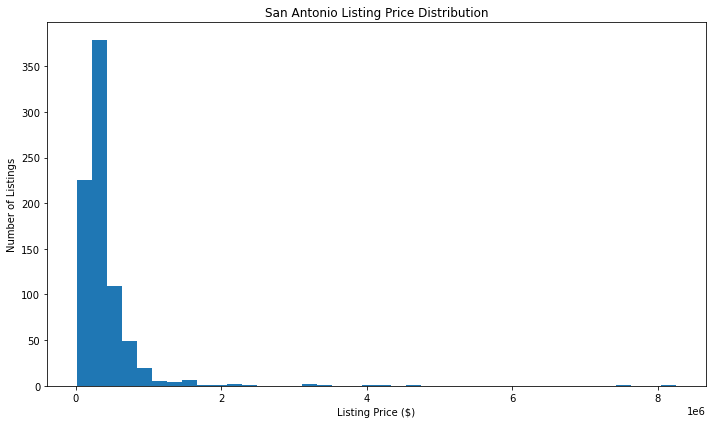

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df["price"].dropna(), bins=40)

ax.set_title("San Antonio Listing Price Distribution")
ax.set_xlabel("Listing Price ($)")
ax.set_ylabel("Number of Listings")

plt.tight_layout()
plt.show()

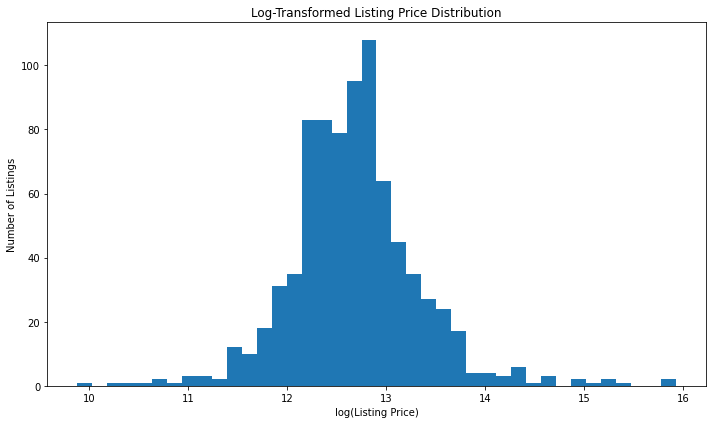

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df["logPrice"].dropna(), bins=40)

ax.set_title("Log-Transformed Listing Price Distribution")
ax.set_xlabel("log(Listing Price)")
ax.set_ylabel("Number of Listings")

plt.tight_layout()
plt.show()

## 5. Property Characteristics

The analysis examines how listing prices vary with major property characteristics, including:

- Living area
- Bedrooms
- Bathrooms
- Lot area
- Tax-assessed value
- Days on Zillow

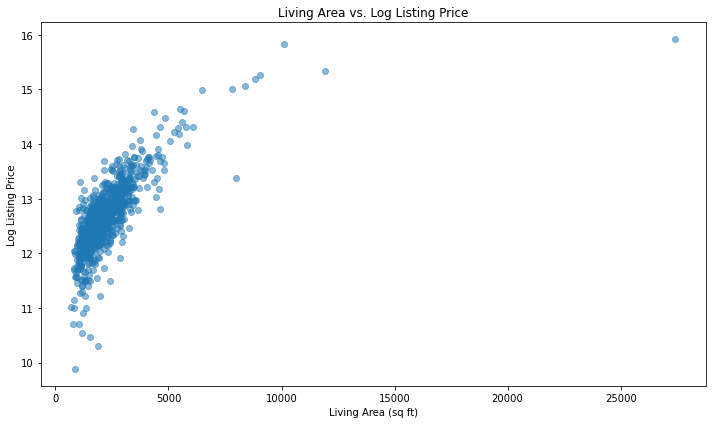

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df["area"],
    df["logPrice"],
    alpha=0.5
)

ax.set_title("Living Area vs. Log Listing Price")
ax.set_xlabel("Living Area (sq ft)")
ax.set_ylabel("Log Listing Price")

plt.tight_layout()
plt.show()

In [17]:
bedroom_summary = (
    df.groupby("beds")["price"]
      .agg(["count", "mean", "median"])
      .sort_index()
)

bedroom_summary

,count,mean,median
beds,,,
1.00,2,"402,450.00","402,450.00"
2.00,45,"238,075.00","220,000.00"
3.00,360,"284,949.90","252,500.00"
4.00,294,"429,520.45","365,000.00"
5.00,79,"679,971.16","489,000.00"
6.00,22,"1,419,581.82","508,000.00"
7.00,3,"2,922,333.33","3,950,000.00"
8.00,1,"552,000.00","552,000.00"
10.00,2,"1,380,000.00","1,380,000.00"


In [18]:
bathroom_summary = (
    df.groupby("baths")["price"]
      .agg(["count", "mean", "median"])
      .sort_index()
)

bathroom_summary

,count,mean,median
baths,,,
1.00,36,"166,679.14","142,450.00"
1.50,1,"165,000.00","165,000.00"
2.00,355,"266,748.57","249,999.00"
3.00,280,"373,790.04","348,950.00"
4.00,93,"613,393.23","536,000.00"
5.00,21,"1,048,138.00","915,000.00"
6.00,14,"1,082,778.57","925,000.00"
7.00,3,"5,091,666.67","4,300,000.00"
8.00,1,"650,000.00","650,000.00"


## 6. Correlation Analysis

Correlation analysis is used to identify relationships between listing price and numerical property characteristics.

Correlation measures association rather than causation. These relationships are therefore interpreted as descriptive patterns within the dataset rather than causal effects.

In [19]:
correlation_columns = [
    "price",
    "logPrice",
    "area",
    "beds",
    "baths",
    "lotAreaSqFt",
    "taxAssessedValue",
    "daysOnZillow"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix["price"].sort_values(ascending=False)

price              1.00
taxAssessedValue   0.94
area               0.87
logPrice           0.74
baths              0.70
beds               0.37
lotAreaSqFt        0.36
daysOnZillow       0.08
Name: price, dtype: float64

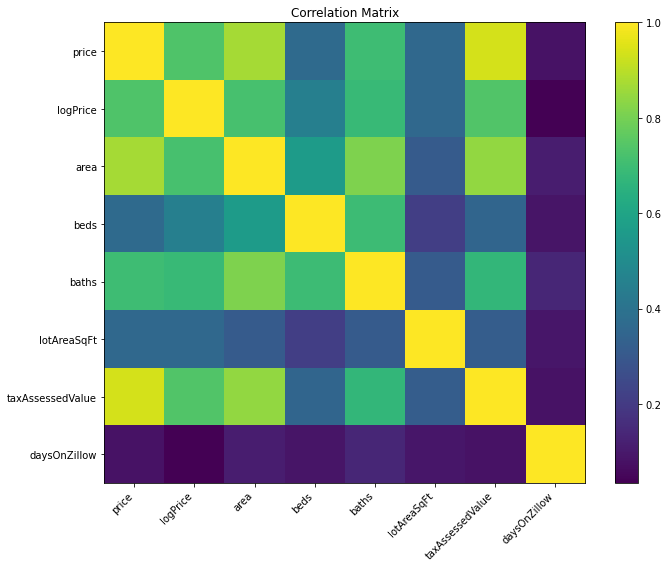

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(correlation_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))

ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)

ax.set_title("Correlation Matrix")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 7. ZIP Code Analysis

Housing prices vary substantially across San Antonio ZIP codes.

To reduce the risk of drawing conclusions from very small samples, ZIP codes with fewer than 10 valid listings are classified as sparse and are excluded from standalone ZIP rankings.

ZIP codes with at least 10 listings are considered sufficiently sampled for comparative analysis.

In [21]:
zip_summary = (
    df.groupby("zipcode")
      .agg(
          listing_count=("zpid", "count"),
          median_price=("price", "median"),
          median_price_per_sqft=("pricePerSqFt", "median"),
          median_area=("area", "median"),
          median_days_on_zillow=("daysOnZillow", "median")
      )
      .reset_index()
)

zip_summary["sample_status"] = np.where(
    zip_summary["listing_count"] >= 10,
    "Sufficient Sample",
    "Sparse Sample"
)

zip_summary.sort_values(
    ["listing_count", "median_price"],
    ascending=[False, False]
).head(20)

,zipcode,listing_count,median_price,median_price_per_sqft,median_area,median_days_on_zillow,sample_status
40,78245,49,"250,000.00",129.56,"1,910.00",12.00,Sufficient Sample
47,78253,48,"336,500.00",156.47,"2,217.00",9.00,Sufficient Sample
48,78254,39,"350,000.00",147.51,"2,392.00",20.00,Sufficient Sample
52,78258,38,"659,950.00",198.69,"3,252.50",25.50,Sufficient Sample
30,78230,33,"375,000.00",186.83,"2,283.00",34.00,Sufficient Sample
41,78247,32,"274,999.50",147.89,"1,902.00",25.00,Sufficient Sample
44,78250,31,"225,000.00",150.53,"1,606.00",11.00,Sufficient Sample
13,78212,28,"360,000.00",191.74,"1,820.00",60.50,Sufficient Sample
43,78249,27,"328,900.00",169.22,"1,921.00",30.00,Sufficient Sample
16,78216,27,"325,000.00",181.41,"2,003.00",19.00,Sufficient Sample


In [22]:
sufficient_zip_summary = zip_summary[
    zip_summary["listing_count"] >= 10
].copy()

sufficient_zip_summary.sort_values(
    "median_price",
    ascending=False
).head(10)

,zipcode,listing_count,median_price,median_price_per_sqft,median_area,median_days_on_zillow,sample_status
51,78257,11,"3,475,000.00",385.10,"8,390.00",32.00,Sufficient Sample
49,78255,23,"700,000.00",253.66,"3,154.00",22.00,Sufficient Sample
52,78258,38,"659,950.00",198.69,"3,252.50",25.50,Sufficient Sample
55,78261,14,"606,000.00",234.88,"2,810.00",4.00,Sufficient Sample
54,78260,22,"512,500.00",199.15,"2,551.00",32.00,Sufficient Sample
42,78248,19,"489,950.00",190.46,"2,665.00",32.00,Sufficient Sample
10,78209,20,"399,500.00",248.35,"1,664.50",17.00,Sufficient Sample
53,78259,17,"397,500.00",175.58,"2,330.00",38.00,Sufficient Sample
30,78230,33,"375,000.00",186.83,"2,283.00",34.00,Sufficient Sample
13,78212,28,"360,000.00",191.74,"1,820.00",60.50,Sufficient Sample


In [23]:
sufficient_zip_summary.sort_values(
    "median_price",
    ascending=True
).head(10)

,zipcode,listing_count,median_price,median_price_per_sqft,median_area,median_days_on_zillow,sample_status
23,78223,13,"179,000.00",114.75,"1,393.00",37.00,Sufficient Sample
36,78239,14,"182,500.00",121.79,"1,658.50",14.00,Sufficient Sample
11,78210,13,"189,000.00",137.25,"1,347.00",49.00,Sufficient Sample
33,78233,17,"190,000.00",131.22,"1,588.00",13.00,Sufficient Sample
27,78227,10,"194,950.00",137.81,"1,269.50",24.50,Sufficient Sample
21,78221,11,"200,000.00",125.18,"1,729.00",61.00,Sufficient Sample
28,78228,17,"219,990.00",130.87,"1,524.00",12.00,Sufficient Sample
17,78217,10,"224,450.00",148.75,"1,484.00",6.50,Sufficient Sample
39,78244,19,"224,900.00",115.16,"2,042.00",33.00,Sufficient Sample
44,78250,31,"225,000.00",150.53,"1,606.00",11.00,Sufficient Sample


## 8. Property-Type Analysis

Property type provides additional context for interpreting differences in listing prices.

Price differences across ZIP codes should therefore not be interpreted independently of property characteristics and property-type composition.

In [26]:
property_type_summary = (
    df.groupby("homeType")["price"]
      .agg(["count", "mean", "median"])
      .sort_values("median", ascending=False)
)

property_type_summary

,count,mean,median
homeType,,,
MULTI_FAMILY,22,"374,720.45","387,500.00"
SINGLE_FAMILY,761,"426,537.91","314,900.00"
CONDO,13,"232,775.08","249,777.00"
TOWNHOUSE,10,"245,740.00","232,000.00"
MANUFACTURED,4,"95,998.75","57,497.50"


## 9. Zestimate Analysis

Zillow Zestimate values are examined separately from the predictive modeling workflow.

A positive Zestimate gap indicates that the Zestimate is greater than the observed listing price:

$$
Zestimate\ Gap = Zestimate - Listing\ Price
$$

The percentage gap is:

$$
Zestimate\ Gap\ \% =
\frac{Zestimate - Listing\ Price}{Listing\ Price}
\times 100
$$

Missing Zestimate values remain missing and are not treated as zero.

Properties where Zestimate exceeds listing price are described as **potential opportunities**, not guaranteed investment opportunities.

In [27]:
zestimate_df = df[df["zestimate"].notna()].copy()

print(f"Listings with Zestimate: {len(zestimate_df):,}")
print(f"Listings without Zestimate: {df['zestimate'].isna().sum():,}")
print(
    f"Zestimate coverage: "
    f"{df['zestimate'].notna().mean() * 100:.2f}%"
)

Listings with Zestimate: 576
Listings without Zestimate: 234
Zestimate coverage: 71.11%


In [28]:
zestimate_df[[
    "price",
    "zestimate",
    "zestimate_gap",
    "zestimate_gap_pct"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
price,576.00,"443,182.94","586,945.38","19,500.00","239,675.00","325,000.00","452,500.00","8,250,000.00"
zestimate,576.00,"431,383.33","540,638.20","17,900.00","234,950.00","315,800.00","448,925.00","7,313,900.00"
zestimate_gap,576.00,"-11,799.61","54,938.33","-936,100.00","-11,100.00","-5,300.00","-2,900.00","164,060.00"
zestimate_gap_pct,576.00,-0.01,0.12,-0.45,-0.03,-0.02,-0.01,1.69


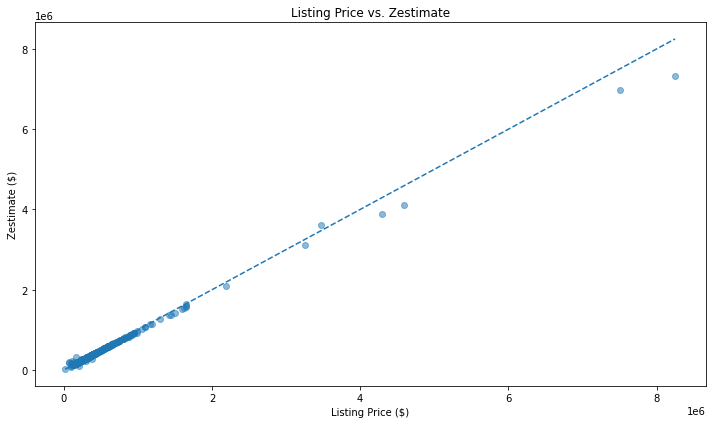

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    zestimate_df["price"],
    zestimate_df["zestimate"],
    alpha=0.5
)

min_value = min(
    zestimate_df["price"].min(),
    zestimate_df["zestimate"].min()
)

max_value = max(
    zestimate_df["price"].max(),
    zestimate_df["zestimate"].max()
)

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

ax.set_title("Listing Price vs. Zestimate")
ax.set_xlabel("Listing Price ($)")
ax.set_ylabel("Zestimate ($)")

plt.tight_layout()
plt.show()

## 10. Potential Zestimate-Based Opportunities

A property is classified as a potential opportunity when its Zestimate exceeds its listing price.

The project's final analysis identified **16 potential opportunities** within the listings with available Zestimate values.

These observations are screening signals rather than evidence of guaranteed investment returns. Zestimate differences may reflect property characteristics, market conditions, listing information, or limitations of automated valuation models.

In [30]:
opportunities = zestimate_df[
    zestimate_df["zestimate"] > zestimate_df["price"]
].copy()

print(f"Potential opportunities: {len(opportunities)}")

Potential opportunities: 16


In [31]:
opportunities[[
    "zpid",
    "zipcode",
    "price",
    "zestimate",
    "zestimate_gap",
    "zestimate_gap_pct",
    "deal_score"
]].sort_values(
    "zestimate_gap_pct",
    ascending=False
).head(20)

,zpid,zipcode,price,zestimate,zestimate_gap,zestimate_gap_pct,deal_score
73,26223696,78201,"75,000.00","202,000.00","127,000.00",1.69,100.00
567,26303147,78218,"75,000.00","170,800.00","95,800.00",1.28,99.83
109,455954061,78226,"110,000.00","223,600.00","113,600.00",1.03,99.65
68,26347085,78238,"167,640.00","331,700.00","164,060.00",0.98,99.48
614,447450487,78218,"99,999.00","185,600.00","85,601.00",0.86,99.31
396,69228963,78245,"136,000.00","204,900.00","68,900.00",0.51,99.13
74,26277599,78222,"129,900.00","150,000.00","20,100.00",0.15,98.96
474,26452112,78250,"235,000.00","271,000.00","36,000.00",0.15,98.78
392,447422848,78201,"184,900.00","210,300.00","25,400.00",0.14,98.61
421,26381746,78233,"209,900.00","235,200.00","25,300.00",0.12,98.44


## 11. Key EDA Findings

The exploratory analysis produced several important findings that informed the later statistical and machine-learning stages.

### Market Structure

San Antonio's housing listings show substantial variation in listing prices and property size. The distribution is strongly influenced by a smaller number of high-value properties, making median-based comparisons particularly useful for geographic analysis.

### Property Characteristics

Living area, tax-assessed value, lot area, bedrooms, and bathrooms show meaningful relationships with listing price. These variables therefore provide useful candidates for subsequent predictive modeling.

### Geographic Differences

Housing prices vary substantially across ZIP codes. The analysis uses a minimum threshold of 10 listings when producing standalone ZIP-level rankings to reduce the influence of very small samples.

### Zestimate Relationships

Zestimate coverage is incomplete, with 576 of the 810 listings having an available Zestimate, corresponding to approximately 71.11% coverage.

Among listings with available Zestimate values, properties where Zestimate exceeds listing price can be screened as potential opportunities.

### Modeling Implication

The EDA findings informed the machine-learning feature set while maintaining a strict separation between predictive variables and price-derived or Zestimate-derived variables that could introduce leakage.

## 12. Conclusion

The exploratory analysis establishes the structure of the San Antonio housing market represented in the finalized dataset.

The analysis shows substantial variation in listing prices across property characteristics and ZIP codes, while also demonstrating the importance of accounting for skewed price distributions, sample-size differences, missing Zestimate values, and extreme observations.

These findings provide the foundation for the project's statistical analysis and machine-learning stages.

The next stage evaluates statistical relationships and develops predictive models using a leakage-safe set of housing characteristics.